In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pywt

import os
os.chdir("../../..")

from scripts.NEURON_Sim_Wrapper import Network

In [2]:
file_path = "./Datasets/Generated/Experiments/LLM_Synapses_Experiments/3k_inh-exc-LLM_70con_2000ms_stim_input_all_amp02_1000ms_000059synweight_2syndelay.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)
    
t = data['t']
voltages = data['voltages']



# # Remove this
# # --- 1. Расширяем t до 5000 ---
# dt = t[1] - t[0]  # шаг (0.25)
# t_extended = np.arange(0, 5000 + dt, dt)

# # --- 2. Обрабатываем voltages ---
# new_voltages = {}

# for neuron_id, v in voltages.items():
#     v = np.array(v)
    
#     half_idx = len(v) // 2
#     last_half = v[half_idx:]  # последняя половина
    
#     # повторяем 8 раз
#     repeated = np.tile(last_half, 8)
    
#     # подгоняем под длину t_extended
#     if len(repeated) < len(t_extended):
#         # если вдруг не хватило — доклеим ещё
#         extra = np.tile(last_half, int(np.ceil((len(t_extended) - len(repeated)) / len(last_half))))
#         repeated = np.concatenate([repeated, extra])
    
#     new_voltages[neuron_id] = repeated[:len(t_extended)]

# t = t_extended
# voltages = new_voltages




sr = 0.00025
real_time_ms = int(len(t)*sr*1000)

print(f"t: {len(t)} sampls ({real_time_ms} ms) ")
print("neurons:", len(list(voltages.keys())))
print("voltages:", len(voltages["8980589"]))

t: 8001 sampls (2000 ms) 
neurons: 3016
voltages: 8001


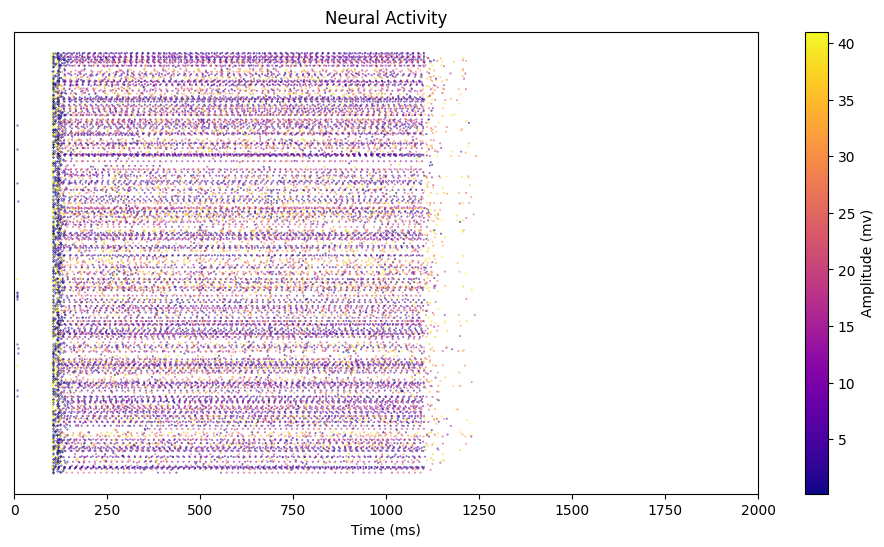

In [3]:
spike_times, spike_amps = Network.analyze(self=None, t=t, voltages=voltages)


# создание графика
fig, ax = plt.subplots(figsize=(12, 6))

# итерация по нейронам
amps_values = []
for i, neuron_id in enumerate(spike_times):
    times = spike_times[neuron_id]
    amps = spike_amps[neuron_id]

    # рисование спайков
    ax.scatter(times, [i] * len(times), s=0.1, c=amps, cmap='plasma')
    amps_values.extend(amps)

# настройка графика
ax.set_xlabel('Time (ms)')
ax.set_yticks([])  # убираем отметки на оси Y
ax.set_title('Neural Activity')
ax.set_xlim(0, real_time_ms)

# добавление цветовой шкалы
if amps_values:  # проверяем, что список не пуст
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=min(amps_values), vmax=max(amps_values))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Amplitude (mv)')

# отображение графика
plt.show()

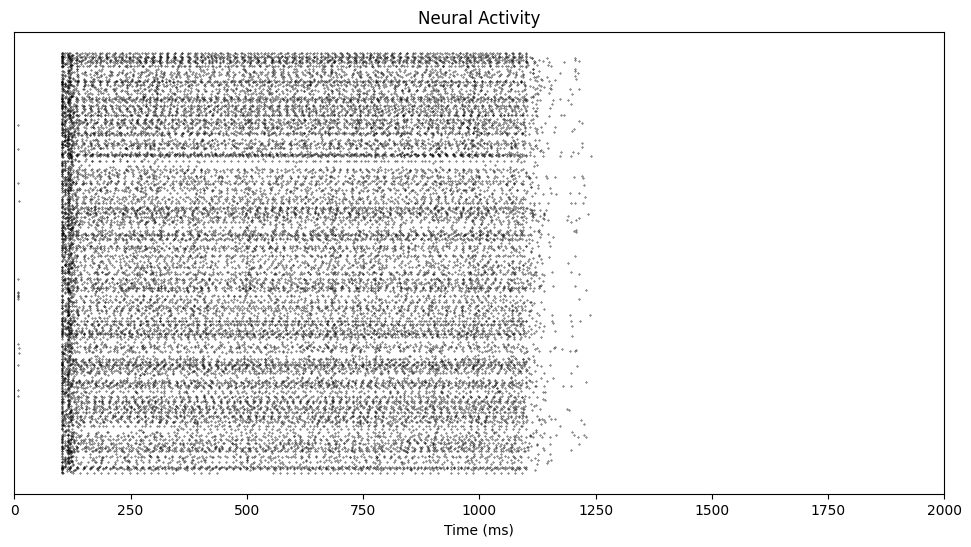

In [4]:
# создание графика
fig, ax = plt.subplots(figsize=(12, 6))

# итерация по нейронам
for i, neuron_id in enumerate(spike_times):
    times = spike_times[neuron_id]

    # рисование спайков (все черные)
    ax.scatter(times, [i] * len(times), s=0.1, color='black')

# настройка графика
ax.set_xlabel('Time (ms)')
ax.set_yticks([])  # убираем отметки на оси Y
ax.set_title('Neural Activity')
ax.set_xlim(0, real_time_ms)

# отображение графика
plt.show()

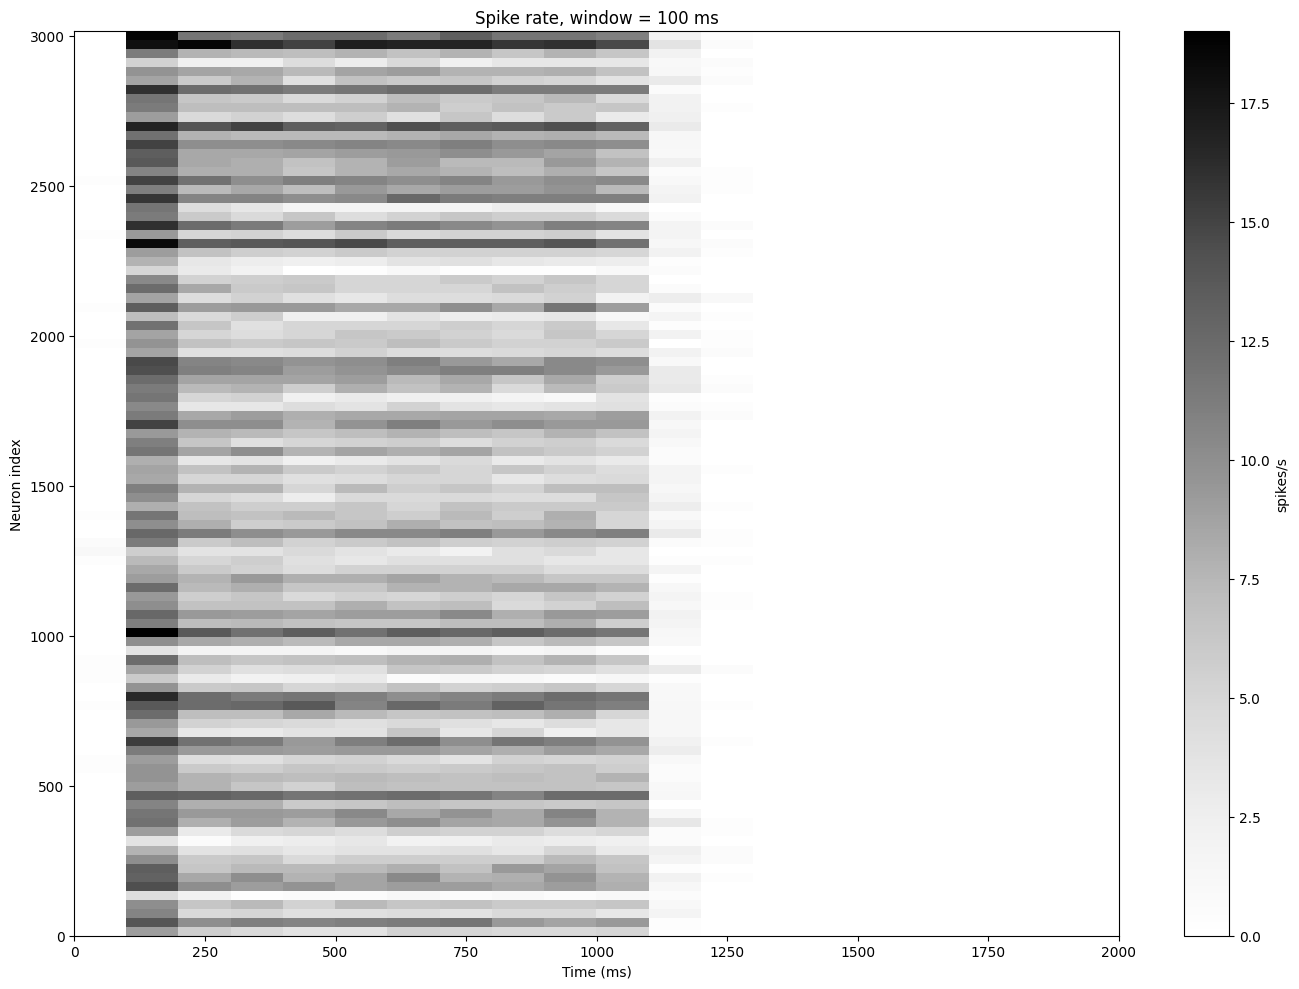

In [5]:
# TODO отсортировать по кластерам из статьи

# Spike rate (Гц); по цвету — log₁₀(1 + Hz), чтобы сжать большой динамический диапазон
window_ms = 100

t_min = float(np.min(t))
t_max = float(np.max(t))
bin_edges = [t_min]
while bin_edges[-1] < t_max:
    bin_edges.append(min(bin_edges[-1] + window_ms, t_max))
bin_edges = np.asarray(bin_edges, dtype=float)

durations_s = np.diff(bin_edges) / 1000.0
n_bins = len(durations_s)
neuron_ids = list(spike_times.keys())
n_neurons = len(neuron_ids)

rate_matrix = np.zeros((n_neurons, n_bins))
for i, nid in enumerate(neuron_ids):
    times = np.asarray(spike_times[nid], dtype=float)
    if times.size:
        counts, _ = np.histogram(times, bins=bin_edges)
        rate_matrix[i, :] = counts / durations_s

# rate_matrix = np.log(rate_matrix + 1.0)

# REMOVE THIS Averaging by groups
group_size = 30
n_groups = n_neurons // group_size
rate_matrix = rate_matrix[:n_groups*group_size].reshape(n_groups, group_size, -1).mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(
    rate_matrix,
    # vmin=vmin, 
    # vmax=vmax,
    aspect="auto",
    origin="lower",
    cmap="Grays",
    extent=(bin_edges[0], bin_edges[-1], -0.5, n_neurons - 0.5),
    interpolation="nearest",
)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Neuron index")
ax.set_title(f"Spike rate, window = {window_ms} ms")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("spikes/s")
plt.tight_layout()
plt.show()

In [4]:
io_neurons = pd.read_csv("./Datasets/Generated/IO_Neurons.csv", index_col="Unnamed: 0")

# Get only input neurons
output_neurons = io_neurons[io_neurons["IO"] == "output"]

output_neurons = output_neurons[output_neurons["celltype"] == "DN-VNC"]
# output_neurons["additional_annotations"].unique()
# # Get only visual
# input_neurons = input_neurons[input_neurons["additional_annotations"]=="visual"]

# input_neurons = list(input_neurons["neuron_id"].astype("string"))

# print(f"Input neurons: {len(input_neurons)}")
output_neurons

,neuron_id,celltype,additional_annotations,IO
19,1065967,DN-VNC,no official annotation,output
44,1622901,DN-VNC,no official annotation,output
46,1678567,DN-VNC,no official annotation,output
60,1980134,DN-VNC,no official annotation,output
120,2669844,DN-VNC,no official annotation,output
...,...,...,...,...
2954,19361427,DN-VNC,no official annotation,output
2957,19508873,DN-VNC,no official annotation,output
2996,20556072,DN-VNC,no official annotation,output
2999,20911955,DN-VNC,no official annotation,output


In [7]:
s2 = pd.read_csv('./Datasets/Original/s2.csv')
s3 = pd.read_csv('./Datasets/Original/s3.csv')
s4 = pd.read_csv('./Datasets/Original/s4.csv')
out = pd.read_csv('./Datasets/Original/outputs.csv', index_col=0)
s2

,left_id,right_id,celltype,additional_annotations,level_7_cluster
0,no pair,2532841,sensory,visual,0
1,no pair,16267292,sensory,visual,0
2,no pair,2544902,sensory,visual,0
3,2216445,no pair,sensory,visual,0
4,2216131,no pair,sensory,visual,0
...,...,...,...,...,...
1368,15713206,15629888,sensory,gustatory-external,no cluster
1369,15998319,15594038,sensory,gustatory-pharyngeal,no cluster
1370,5120990,4044654,sensory,gustatory-external,no cluster
1371,15998913,15508475,sensory,gustatory-pharyngeal,no cluster


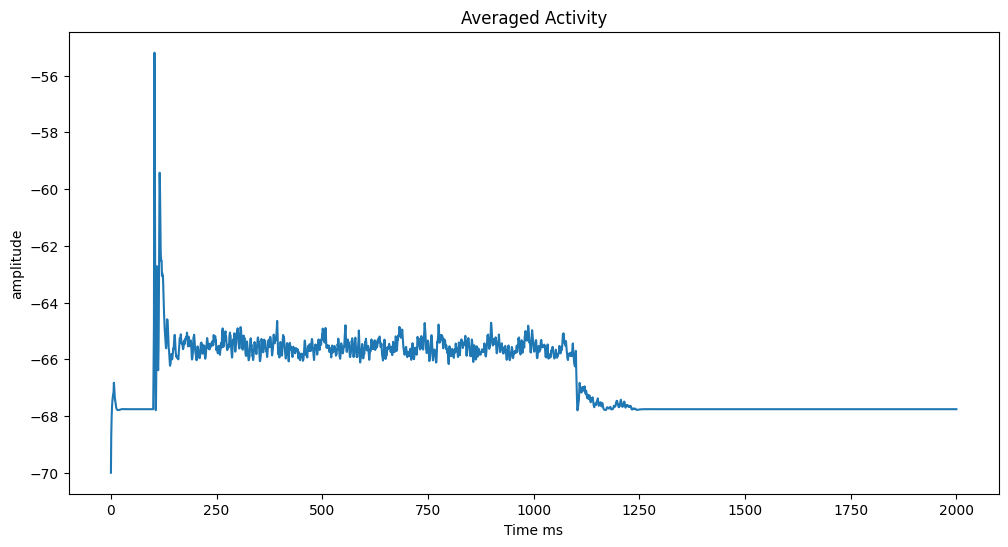

In [8]:
# извлекаем напряжения всех нейронов
all_voltages = list(voltages.values())

# усредняем напряжения по нейронам
averaged_voltages = np.mean(all_voltages, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(t, averaged_voltages)
plt.xlabel('Time ms')
plt.ylabel('amplitude')
plt.title('Averaged Activity')
plt.show()

## Signal Preprocessing

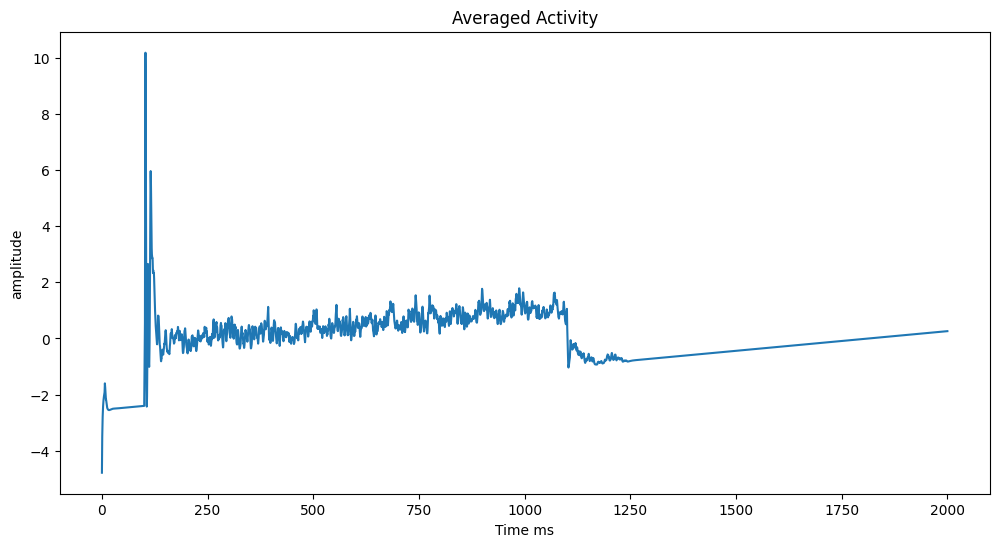

In [9]:
from scipy.signal import detrend, iirnotch, filtfilt

fs = 1 / sr

# 1. Убрать тренд
signal = detrend(averaged_voltages)

# 2. Убрать DC (detrend обычно справляется, но на всякий случай)
signal = signal - np.mean(signal)

# 3. Notch 100 Hz (если нужно)
# b, a = iirnotch(100.0, Q=30, fs=fs)
# signal = filtfilt(b, a, signal)

signal_preproc = signal

plt.figure(figsize=(12, 6))
plt.plot(t, signal_preproc)
plt.xlabel('Time ms')
plt.ylabel('amplitude')
plt.title('Averaged Activity')
plt.show()

## Spectrums

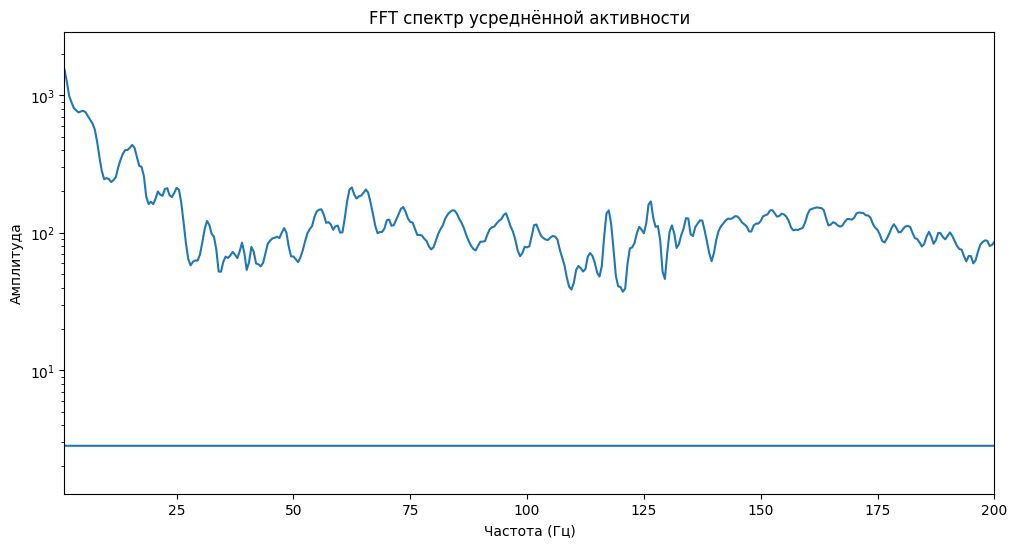

In [10]:
# применяем FFT к усреднённым напряжениям
fft = np.fft.fft(signal_preproc)
freqs = np.fft.fftfreq(len(t), d=sr)

# сглаживаем спектр
sigma = 1  # параметр сглаживания (подбери подходящее значение)
smoothed_fft = gaussian_filter1d(np.abs(fft), sigma)
# smoothed_fft = np.abs(fft)

# рисуем спектр
plt.figure(figsize=(12, 6))
plt.plot(freqs, smoothed_fft)
plt.xlim([1, 200])
# plt.ylim([-10000, 10000])
plt.yscale('log')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('FFT спектр усреднённой активности')
plt.show()

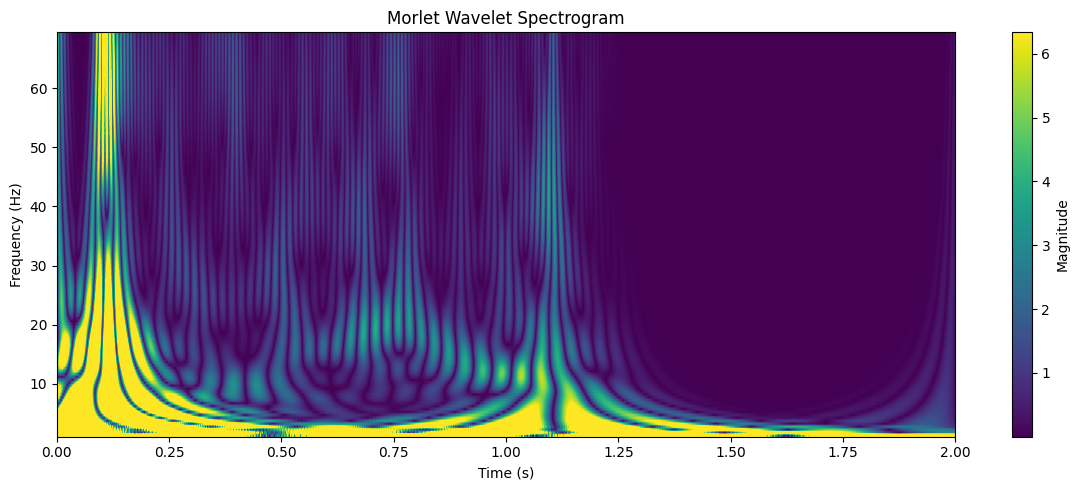

In [11]:
fs = 1 / sr


wavelet = 'morl'
min_freq = 1   # Hz
max_freq = 70  # Hz
resolution = 0.5  # Hz
sensativity = 5 # Percentile


freqs = np.arange(min_freq, max_freq, resolution)

fc = pywt.central_frequency(wavelet)  # ≈ 0.8125

# ПРАВИЛЬНАЯ формула: scales = fc / (freqs * sampling_period)
scales = fc / (freqs * sr)

coef, freqs_wavelet = pywt.cwt(
    signal_preproc,
    scales,
    wavelet,
    sampling_period=sr  # передаём период, не частоту
)

# Реальная длина сигнала во времени
n_samples = len(signal_preproc)
t_end = n_samples * sr # в секундах

magnitude = np.abs(coef)

# Обрезаем верхние X% — хвосты не будут доминировать
vmin = np.percentile(magnitude, 5)
vmax = np.percentile(magnitude, 100-sensativity)

# --- Визуализация ---
plt.figure(figsize=(12, 5))
plt.imshow(
    magnitude,
    extent=[0, t_end, freqs_wavelet.min(), freqs_wavelet.max()],
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Morlet Wavelet Spectrogram")
plt.colorbar(label="Magnitude")
plt.tight_layout()
plt.show()